In [1]:
import sys
import numpy as np
import os
import json

# Add the directory containing instruments.py to the Python path
custom_module_path = "/home/rebeccaz/Github/vampires_calibration"
sys.path.append(custom_module_path)

import plotting_rewrite as plotting
import instruments_jax as inst

# Step 1: Defining System Dictionary

In [2]:
filter_wavelength = 610
wavelength_string = filter_wavelength
wavelength_index = 0
nsteps = 1200000
obs_mode = "MBI"

IPOL_em_gains = [1.14, 1.18, 1.18, 1.18]
MBI_em_gains = [1.23, 1.19, 1.2, 1.08]
if obs_mode == "IPOL":
    em_gain = IPOL_em_gains[wavelength_index]
elif obs_mode == "MBI":
    em_gain = MBI_em_gains[wavelength_index]

system_dict = {
    "components": {
        "wollaston": {
            "type": "wollaston_prism_function",
            "properties": {"beam": "o", "transmission_ratio": em_gain},
        },
        "dichroic": {
            "type": "diattenuator_retarder_function",
            "properties": {"phi": 0, "epsilon": 0, "theta" : 0},
        },
        "flc": {
            "type": "general_retarder_function",
            "properties": {"phi": 0.5 * 2 * np.pi, "theta": 0, "delta_theta": 0},
        },
        "optics": {
            "type": "diattenuator_retarder_function",
            "properties": {"phi": 0, "epsilon": 0, "theta": 0},
        },
        "image_rotator": {
            "type": "general_retarder_function",
            "properties": {"phi": 0.5 * 2 * np.pi, "theta": 0, "delta_theta": 0},
        },
        "hwp": {
            "type": "general_retarder_function",
            "properties": {"phi": 0.5 * 2 * np.pi, "theta": 0, "delta_theta": 0},
        },
        "lp": {
            "type": "general_linear_polarizer_function_with_theta",
            "properties": {"theta": 0},
        },
    }
}

h5_file_path = "/home/rebeccaz/Github/vampires_calibration/mcmc/results/FLC_0_43_dichroic_theta_0_pm_10_optics_theta_0_optics_retardance_025_fixing_flc_theta_a_and_b_fixed_start_to_radians/" + str(filter_wavelength) + "nm_" + str(nsteps) + "_steps.h5"
txt_file_path = "/home/rebeccaz/Github/vampires_calibration/scipy_minimize/data_files/produced/FLC_0_to_43_ten_percent_retardance_constraints_dichroic_theta_0_pm_10_optics_theta_0_pm_10_github_retrieved_non-reduced_errors/" + str(filter_wavelength) + "nm.txt"
txt_save_file_path = "/home/rebeccaz/Github/vampires_calibration/mcmc/results/FLC_0_43_dichroic_theta_0_pm_10_optics_theta_0_optics_retardance_025_fixing_flc_theta_a_and_b_fixed_start_to_radians/" + \
    str(wavelength_string) + "nm.txt"

# Step 2: Loading Chains

In [3]:
chain, names = plotting.load_chain_and_labels(h5_file_path, txt_file_path, include_logf=True)

# Check chain shape after loading
print("Chain shape (nsteps, nwalkers, ndim):", chain.shape)


Chain shape (nsteps, nwalkers, ndim): (336664, 28, 13)


## Step 2.5: Autocorrelation Time Diagnostics

In [4]:
import emcee

# Use the full loaded chain by default. Set a different range to estimate tau after burn-in.
autocorr_step_range = (0, None)
autocorr_thin = 1
autocorr_tol = 0  # Use 50 for emcee's usual convergence check; 0 always returns an estimate.

act_start, act_end = autocorr_step_range
if act_end is None:
    act_end = chain.shape[0]

if act_start < 0 or act_end > chain.shape[0] or act_start >= act_end:
    raise ValueError(f"Invalid autocorr_step_range {autocorr_step_range} for chain with {chain.shape[0]} steps.")

act_chain = chain[act_start:act_end:autocorr_thin, :, :]
if act_chain.shape[0] < 2:
    raise ValueError("Autocorrelation calculation needs at least two saved steps.")

autocorr_tau = emcee.autocorr.integrated_time(act_chain, tol=autocorr_tol, quiet=True)
autocorr_tau_steps = autocorr_tau * autocorr_thin
autocorr_nsteps = act_end - act_start
autocorr_neff = act_chain.shape[0] * act_chain.shape[1] / autocorr_tau
recommended_burn_in = int(2 * np.max(autocorr_tau_steps))
recommended_thinning = max(1, int(0.5 * np.min(autocorr_tau_steps)))

print(f"Autocorrelation step range: {act_start} to {act_end} (thin={autocorr_thin})")
print(f"{'parameter':<35} {'tau [steps]':>12} {'nsteps/tau':>12} {'N_eff':>12}")
for name, tau_steps, neff in zip(names, autocorr_tau_steps, autocorr_neff):
    print(f"{name:<35} {tau_steps:12.1f} {autocorr_nsteps / tau_steps:12.1f} {neff:12.0f}")

print(f"Mean tau: {np.mean(autocorr_tau_steps):.1f} steps")
print(f"Max tau: {np.max(autocorr_tau_steps):.1f} steps")
print(f"Recommended burn-in: {recommended_burn_in} steps")
print(f"Recommended thinning: {recommended_thinning} steps")


Autocorrelation step range: 0 to 336664 (thin=1)
parameter                            tau [steps]   nsteps/tau        N_eff
dichroic.phi                              2705.2        124.5         3485
dichroic.epsilon                           775.7        434.0        12153
dichroic.theta                            4603.6         73.1         2048
flc.phi                                   3409.3         98.7         2765
flc.delta_theta                            819.4        410.9        11504
optics.phi                                2641.8        127.4         3568
optics.epsilon                             734.5        458.4        12834
optics.theta                              4255.8         79.1         2215
image_rotator.phi                          635.6        529.7        14832
hwp.phi                                    619.5        543.5        15217
hwp.delta_theta                            631.8        532.9        14921
lp.theta                                   606.2   

# Step 2.6: Apply Recommended Burn-in and Thinning


Using burn-in = 9207 saved steps and thinning = 303 saved steps.
Posterior chain shape (nthinned_steps, nwalkers, ndim): (1081, 28, 13)
Original saved steps included: 9207 to 336447 (1081 thinned samples per walker).
dichroic.phi (waves): 0.42686 -0.05004/+0.03864
dichroic.epsilon (): 0.00170 -0.00124/+0.00243
dichroic.theta (): 6.99946 -1.08690/+1.97987
flc.phi (waves): 0.45609 -0.02644/+0.05142
flc.delta_theta (): -0.19063 -1.00462/+1.01049
optics.phi (waves): 0.32237 -0.05272/+0.09465
optics.epsilon (): 0.01348 -0.00718/+0.00783
optics.theta (): -4.15612 -4.06342/+2.10225
image_rotator.phi (waves): 0.22267 -0.00192/+0.00192
hwp.phi (waves): 0.44746 -0.00220/+0.00215
hwp.delta_theta (): 1.25173 -0.48297/+0.48647
lp.theta (): -0.02980 -0.84370/+0.85175
log_f (): -3.02569 -0.06228/+0.06464


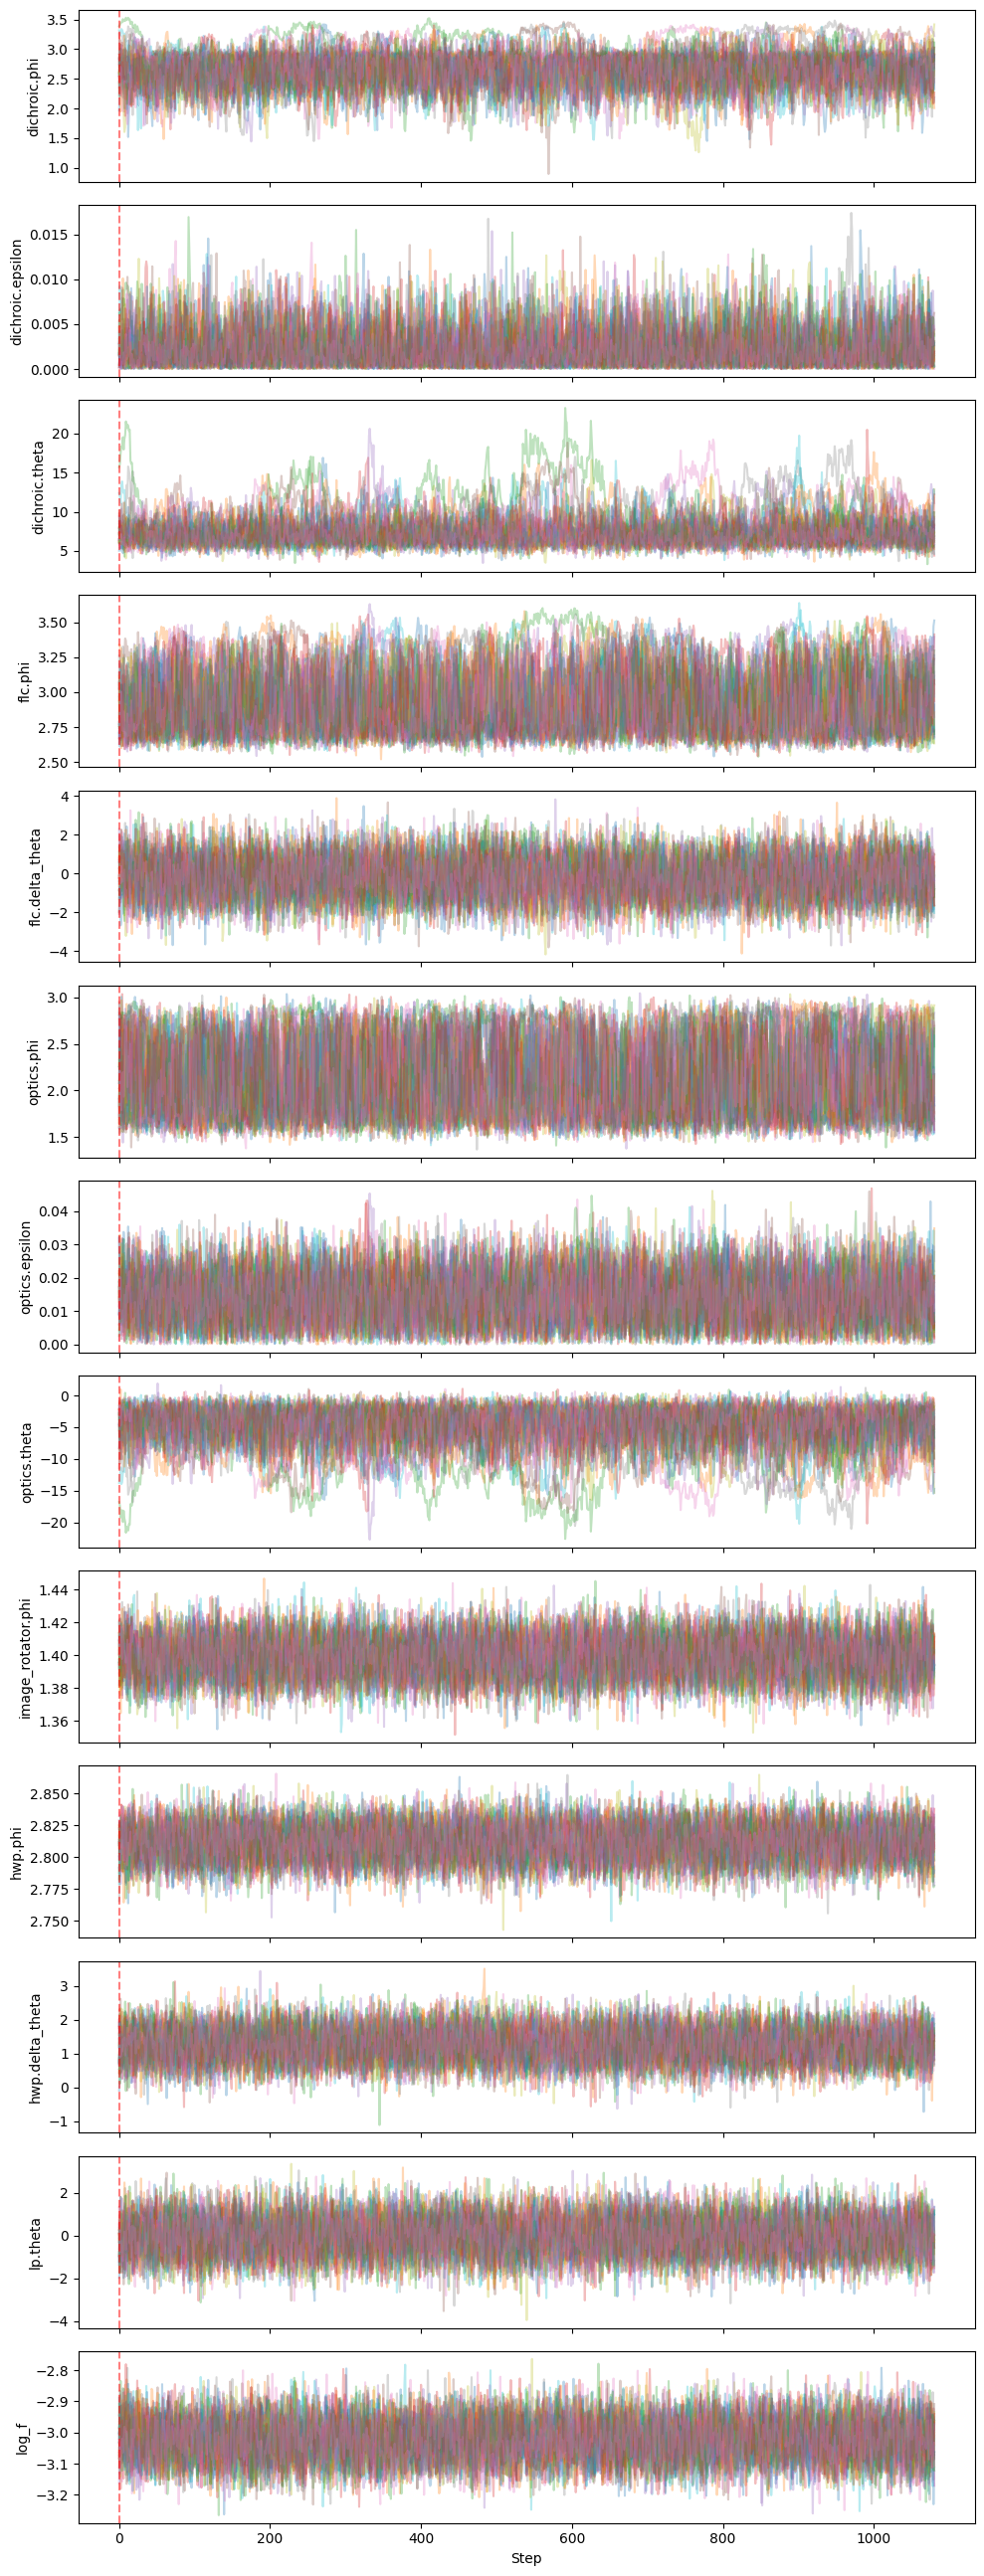

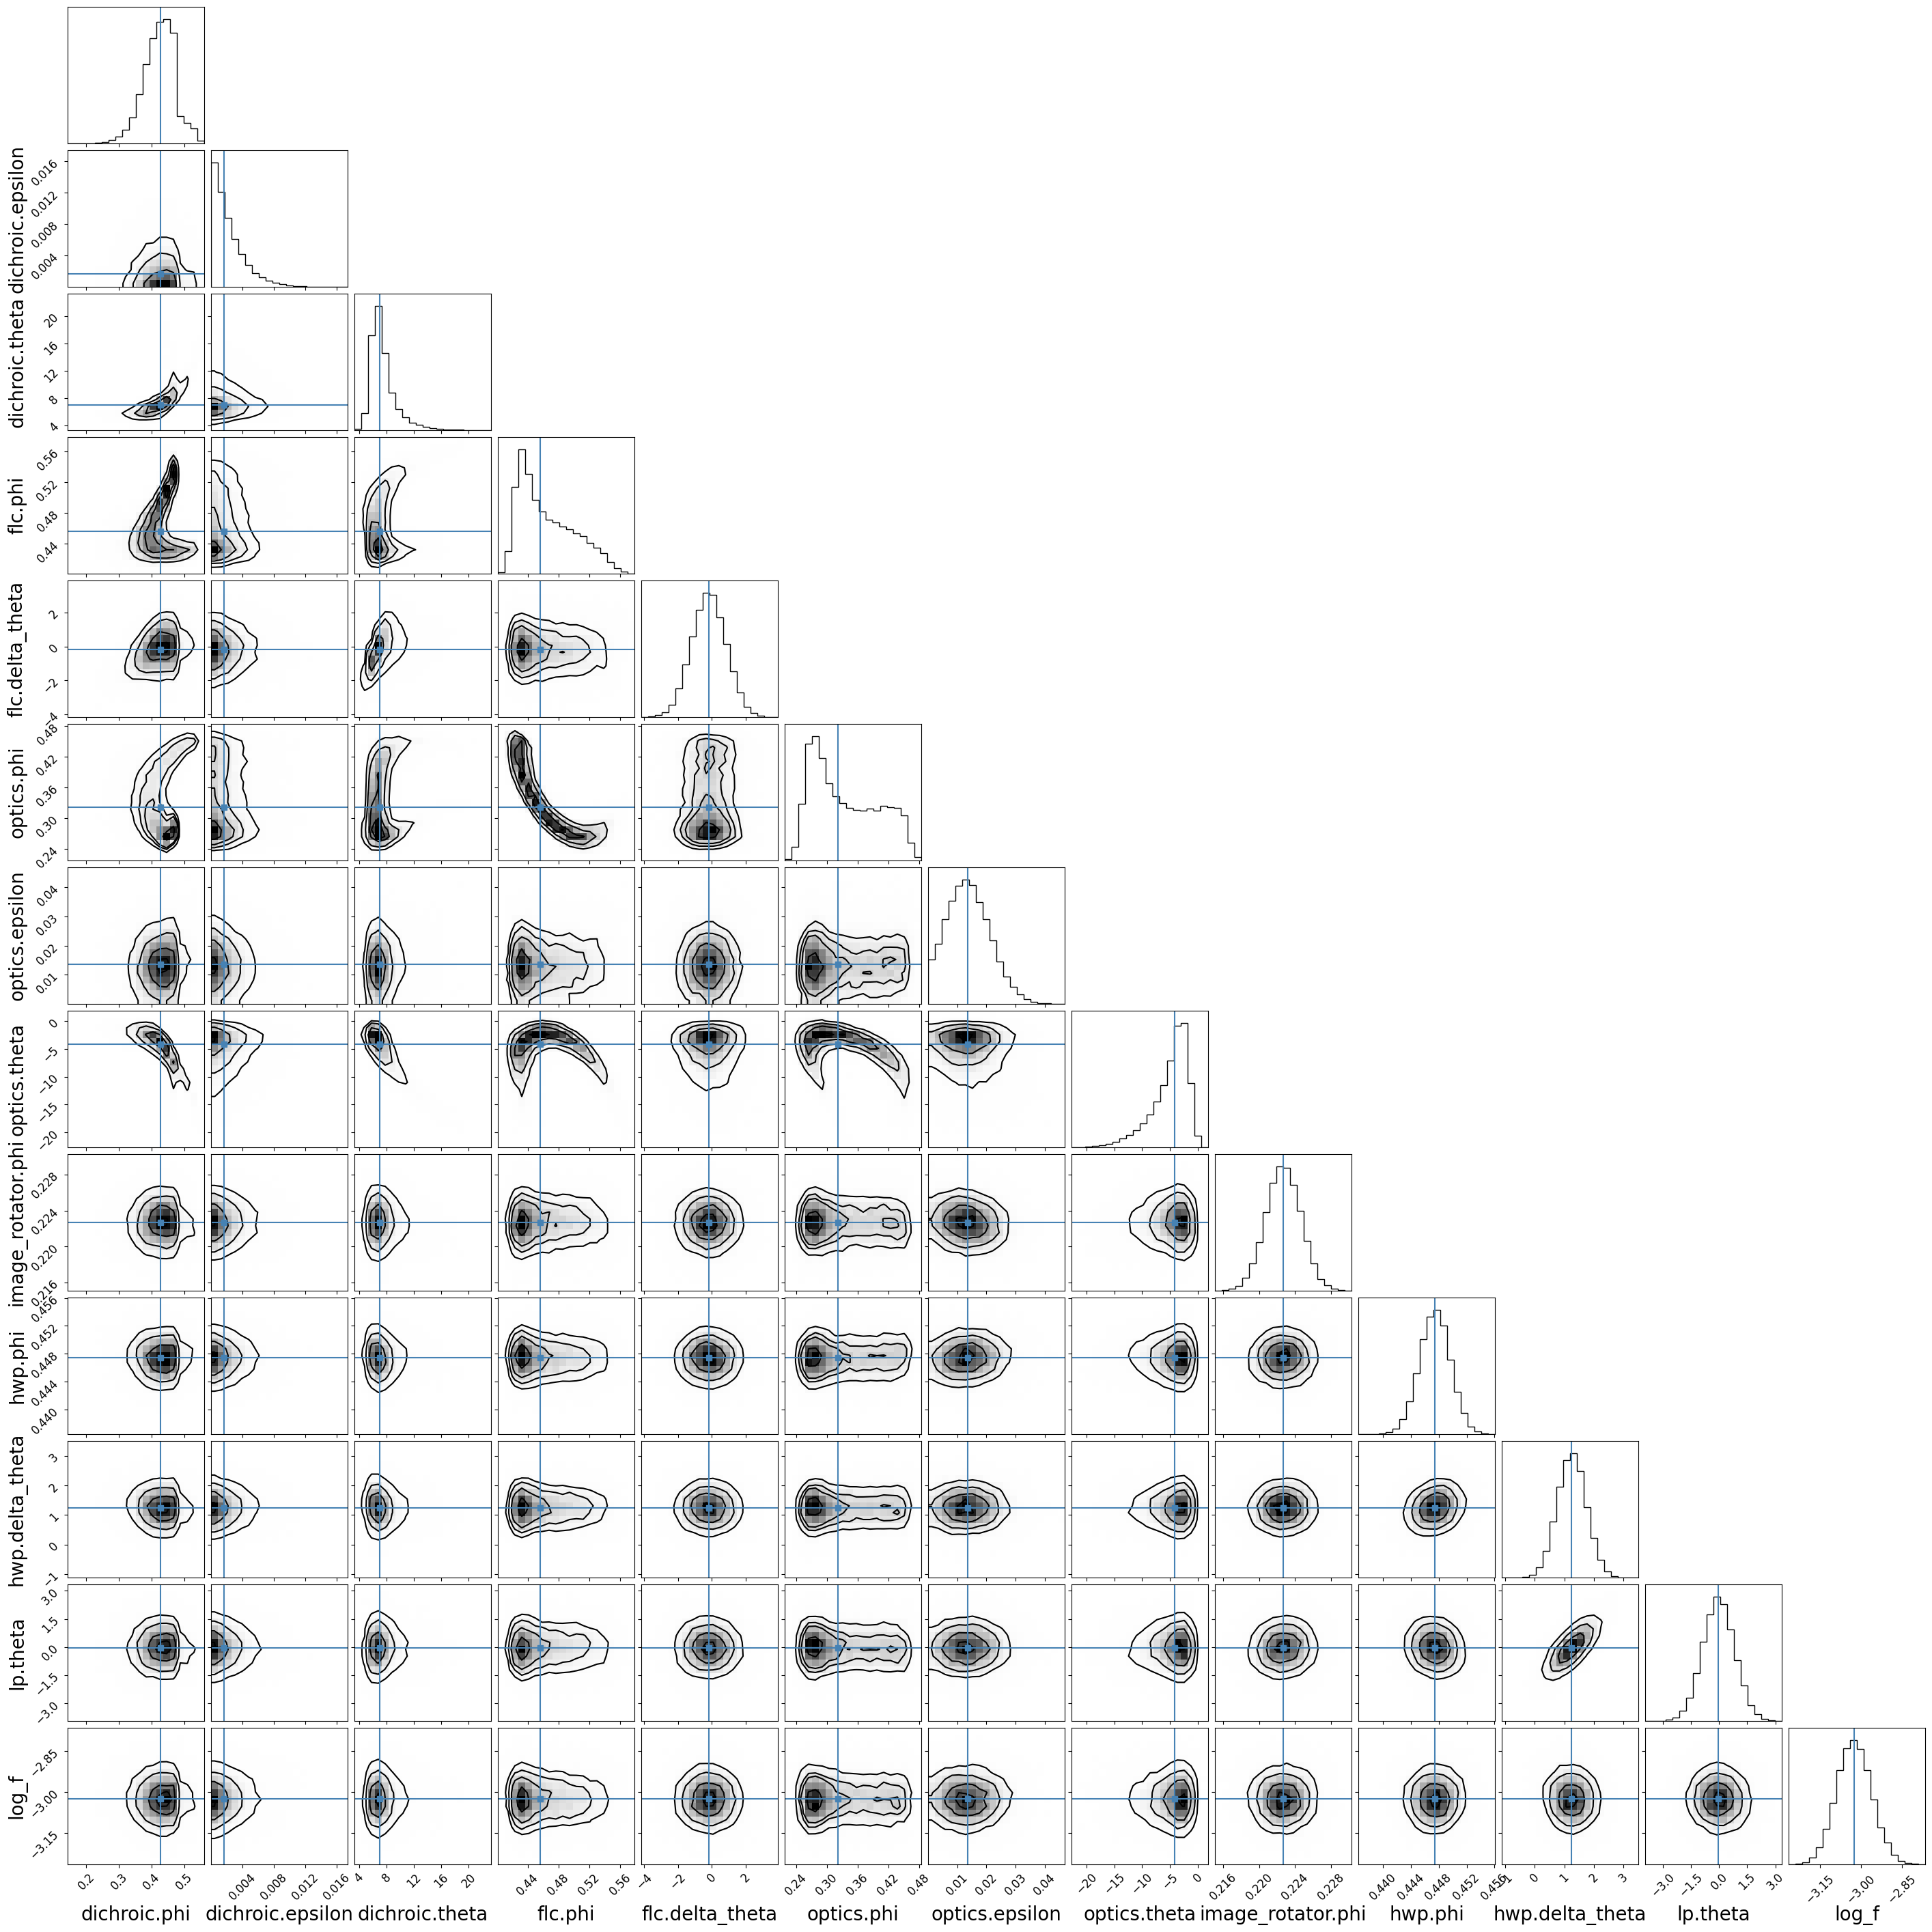

In [5]:
burn_in = recommended_burn_in
thinning = recommended_thinning

if burn_in < 0 or burn_in >= chain.shape[0]:
    raise ValueError(f"Invalid burn_in {burn_in} for chain with {chain.shape[0]} steps.")
if thinning < 1:
    raise ValueError(f"Invalid thinning {thinning}; thinning must be >= 1.")

posterior_chain = chain[burn_in::thinning, :, :]
posterior_step_numbers = np.arange(burn_in, chain.shape[0], thinning)
if posterior_chain.shape[0] < 1:
    raise ValueError("No posterior samples remain after applying burn-in and thinning.")

chain_step_range = (0, None)
corner_plot_step_range = (0, None)

print(f"Using burn-in = {burn_in} saved steps and thinning = {thinning} saved steps.")
print("Posterior chain shape (nthinned_steps, nwalkers, ndim):", posterior_chain.shape)
print(
    f"Original saved steps included: {posterior_step_numbers[0]} to "
    f"{posterior_step_numbers[-1]} ({posterior_chain.shape[0]} thinned samples per walker)."
)

# Print posterior summary for the thinned chain and save the median-fit text file.
posterior_summary = plotting.summarize_posteriors(
    posterior_chain,
    names,
    system_dict,
    step_range=corner_plot_step_range,
    txt_save_file_path=txt_save_file_path,
    txt_file_path=txt_file_path,
    error_mode="percentile",
)

# Plot trace plots after burn-in/thinning.
plotting.plot_trace(posterior_chain, names, step_range=chain_step_range, max_walkers=100)

# Plot corner plot from the flattened thinned posterior chain.
plotting.plot_corner_flat(posterior_chain, names, step_range=corner_plot_step_range)


# Step 3: Plot median configuration of posteriors

In [6]:
filter_wavelength = 610
wavelength_string = filter_wavelength
wavelength_index = 0
nsteps = 1200000
obs_mode = "MBI"

IPOL_em_gains = [1.14, 1.18, 1.18, 1.18]
MBI_em_gains = [1.23, 1.19, 1.2, 1.08]
if obs_mode == "IPOL":
    em_gain = IPOL_em_gains[wavelength_index]
elif obs_mode == "MBI":
    em_gain = MBI_em_gains[wavelength_index]

file_path = "/home/rebeccaz/Github/vampires_calibration/data/20230914_processed_table.csv"
deltas_in_waves = True
import instruments as inst
interleaved_values, interleaved_stds, configuration_list = inst.read_csv(file_path, 
    obs_mode = obs_mode, obs_filter = wavelength_string, flc_a_theta=0, flc_b_theta=43)

In [7]:
# Loading in median parameters
with open(txt_save_file_path, "r") as f:
    past_fit = json.load(f)

# print(past_fit)

theta_pol = past_fit["lp"]["theta"]
delta_HWP = past_fit["hwp"]["phi"]
offset_HWP = past_fit["hwp"]["delta_theta"]
delta_derot = past_fit["image_rotator"]["phi"] 
delta_opts = past_fit["optics"]["phi"] 
epsilon_opts = past_fit["optics"]["epsilon"]
rot_opts = past_fit["optics"]["theta"]
delta_FLC = past_fit["flc"]["phi"] 
rot_FLC = past_fit["flc"]["delta_theta"]
delta_dichroic = past_fit["dichroic"]["phi"]
epsilon_dichroic = past_fit["dichroic"]["epsilon"]
rot_dichroic = past_fit["dichroic"]["theta"]

print("Pre-Adjustment delta_HWP: " + str(delta_HWP))
print("EM Gain: " + str(em_gain))

if deltas_in_waves:
    delta_HWP = delta_HWP * 2 * np.pi
    delta_derot = delta_derot * 2 * np.pi
    delta_opts = delta_opts * 2 * np.pi
    delta_FLC = delta_FLC * 2 * np.pi
    delta_dichroic = delta_dichroic * 2 * np.pi

print("Post-Adjustment delta_HWP: " + str(delta_HWP))

# NOTE: Components must be listed downstream to upstream
# Define the instrument configuration as a system dictionary

system_dict = {
    "components": {
        "wollaston": {
            "type": "wollaston_prism_function",
            "properties": {"beam": "o", "transmission_ratio": em_gain},
        },
        "dichroic": {
            "type": "diattenuator_retarder_function",
            "properties": {
                "phi": delta_dichroic,
                "epsilon": epsilon_dichroic,
                "theta": rot_dichroic,
            },
        },
        "flc": {
            "type": "general_retarder_function",
            "properties": {
                "phi": delta_FLC,
                "theta": 0,  # not fitted
                "delta_theta": rot_FLC,
            },
        },
        "optics": {
            "type": "diattenuator_retarder_function",
            "properties": {
                "phi": delta_opts,
                "epsilon": epsilon_opts,
                "theta": rot_opts,
            },
        },
        "image_rotator": {
            "type": "general_retarder_function",
            "properties": {
                "phi": delta_derot,
                "theta": 0,  # not fitted
                "delta_theta": 0,  # not fitted
            },
        },
        "hwp": {
            "type": "general_retarder_function",
            "properties": {
                "phi": delta_HWP,
                "theta": 0,  # not fitted
                "delta_theta": offset_HWP,
            },
        },
        "lp": {
            "type": "general_linear_polarizer_function_with_theta",
            "properties": {"theta": theta_pol},
        },
    }
}

system_mm = inst.generate_system_mueller_matrix(system_dict)
print(system_mm.evaluate())


Pre-Adjustment delta_HWP: 0.44746478485737196
EM Gain: 1.23
Post-Adjustment delta_HWP: 2.811504161696114
[[ 0.60274313  0.6027428  -0.00062695  0.        ]
 [ 0.60274313  0.6027428  -0.00062695  0.        ]
 [ 0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]]


logl value: 348.24558842575266


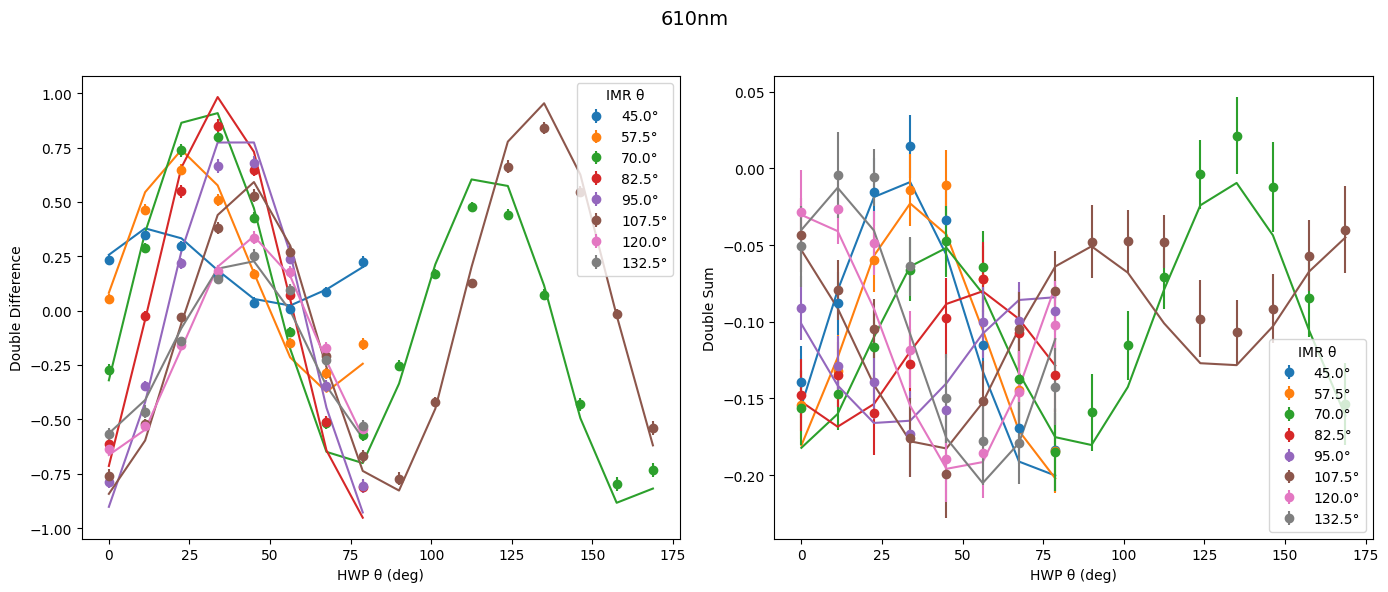

In [8]:
# Fittin for all parameters

p0 = {
    "wollaston": {"transmission_ratio": em_gain}, 
}

p0_values, p0_keywords = inst.parse_configuration(p0)
s_in = np.array([1, 0, 0, 0])
logl_value = inst.logl(p0_values, p0_keywords, system_mm, interleaved_values, interleaved_stds, configuration_list,
    s_in=s_in, logl_function=None, process_dataset=inst.process_dataset, process_errors=inst.process_errors, 
    process_model=inst.process_model)
print("logl value: " + str(logl_value))

# Plotting intial plot
updated_system_mm = inst.update_system_mm(p0_values, p0_keywords, system_mm)
model = inst.model(p0_values, p0_keywords, system_mm, configuration_list, 
    process_model = inst.process_model)

inst.plot_data_and_model(interleaved_values, interleaved_stds, model, 
    configuration_list, wavelength = wavelength_string)

# Step 4: Plotting Random Chains for Fitting (UNDER CONSTRUCTION)

Plotting 100 random thinned posterior samples.
Thinned sample index range: 0 to 1081.
Selected original (step, walker) pairs:
[(152223, 7), (316752, 23), (228276, 16), (161616, 21), (156162, 23), (263727, 1), (59505, 15), (115560, 23), (63141, 7), (243426, 11), (68595, 23), (171918, 8), (150405, 17), (277968, 8), (130407, 1), (236760, 15), (281604, 10), (74958, 3), (299178, 20), (325539, 17), (83442, 2), (310692, 27), (300996, 22), (51021, 3), (61626, 16), (283422, 9), (269484, 8), (71019, 17), (257667, 3), (54960, 2), (87381, 26), (190401, 5), (238275, 17), (181008, 12), (187371, 6), (103440, 17), (305238, 22), (265848, 10), (219489, 8), (260394, 20), (39204, 10), (284634, 18), (187977, 0), (135861, 21), (154041, 6), (164646, 23), (215247, 12), (31326, 8), (257667, 12), (83442, 3), (222822, 9), (303117, 18), (232518, 11), (128892, 23), (154647, 26), (160404, 27), (311904, 8), (176766, 7), (249486, 1), (252213, 14), (140406, 26), (130104, 22), (261606, 26), (34053, 12), (217671, 8), (2

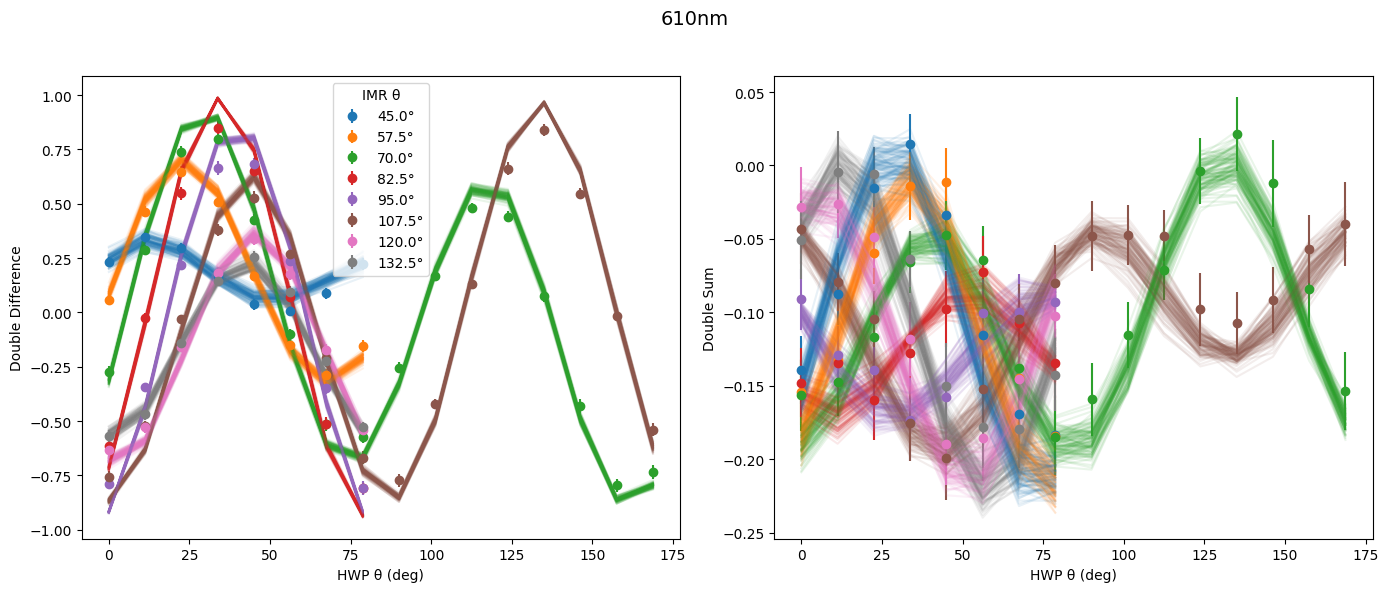

In [9]:
import importlib
import instruments_jax as inst_random
inst_random = importlib.reload(inst_random)

# User settings
n_random_chains = 100
random_chain_step_range = corner_plot_step_range
random_chain_alpha = 0.1
random_seed = 42
imr_theta_filter = None

sampling_chain = globals().get("posterior_chain", chain)
sampling_step_numbers = globals().get("posterior_step_numbers", np.arange(sampling_chain.shape[0]))

with open(txt_file_path, "r") as f:
    fit_param_dict = json.load(f)
_, fit_param_keys = inst_random.parse_configuration(fit_param_dict)

start, end = random_chain_step_range
if end is None:
    end = sampling_chain.shape[0]

if start < 0 or end > sampling_chain.shape[0] or start >= end:
    raise ValueError(
        f"Invalid random_chain_step_range {random_chain_step_range} "
        f"for sampling chain with {sampling_chain.shape[0]} steps."
    )

chain_window = sampling_chain[start:end, :, :]
flat_chain_window = chain_window.reshape(-1, sampling_chain.shape[-1])
n_available_samples = flat_chain_window.shape[0]

if sampling_chain.shape[-1] < len(fit_param_keys):
    raise ValueError(
        f"Chain has {sampling_chain.shape[-1]} parameters, "
        f"but {len(fit_param_keys)} fitted parameters were found."
    )

if n_random_chains > n_available_samples:
    raise ValueError(f"Only {n_available_samples} samples available, but {n_random_chains} requested.")

rng = np.random.default_rng(random_seed)
selected_flat_indices = rng.choice(n_available_samples, size=n_random_chains, replace=False)
selected_sample_indices = start + (selected_flat_indices // sampling_chain.shape[1])
selected_steps = sampling_step_numbers[selected_sample_indices]
selected_walkers = selected_flat_indices % sampling_chain.shape[1]
random_chain_samples = flat_chain_window[selected_flat_indices, :len(fit_param_keys)]
random_chain_system_mm = inst_random.generate_system_mueller_matrix(system_dict)
s_in_random = globals().get("s_in", np.array([1, 0, 0, 0]))

random_chain_models = [
    inst_random.model(
        sample,
        fit_param_keys,
        random_chain_system_mm,
        configuration_list,
        s_in=s_in_random,
        process_model=inst_random.process_model,
    )
    for sample in random_chain_samples
]

print(f"Plotting {n_random_chains} random thinned posterior samples.")
print(f"Thinned sample index range: {start} to {end}.")
print("Selected original (step, walker) pairs:")
print(list(zip(selected_steps.tolist(), selected_walkers.tolist())))

inst_random.plot_data_and_model(
    interleaved_values,
    interleaved_stds,
    random_chain_models,
    configuration_list,
    wavelength=wavelength_string,
    imr_theta_filter=imr_theta_filter,
    model_alpha=random_chain_alpha,
    first_model_alpha=random_chain_alpha,
)


MAP saved step: 78897
MAP walker: 2
MAP log probability: 399.492514


,parameter,MAP value,units,raw chain value
0,dichroic.phi,0.435142,waves,2.734078
1,dichroic.epsilon,0.000017,,0.000017
2,dichroic.theta,6.982264,,6.982264
3,flc.phi,0.491633,waves,3.089023
4,flc.delta_theta,-0.020499,,-0.020499
5,optics.phi,0.281514,waves,1.768807
6,optics.epsilon,0.012052,,0.012052
7,optics.theta,-3.716101,,-3.716101
8,image_rotator.phi,0.223457,waves,1.404019
9,hwp.phi,0.448082,waves,2.815382


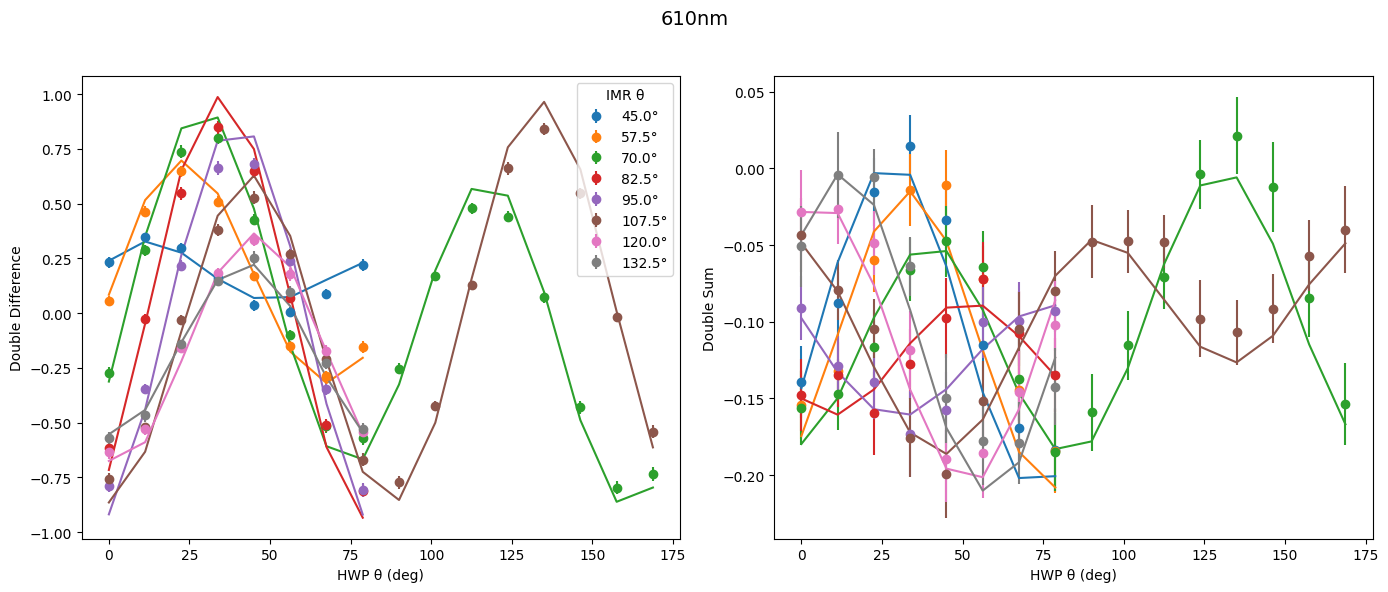

In [10]:
# Step 5: MAP / maximum stored log-probability model
# Note: emcee log_prob includes the prior, so this is the MAP sample when priors are non-flat.
import h5py
import pandas as pd
from IPython.display import display
import importlib
import instruments_jax as inst_map
inst_map = importlib.reload(inst_map)

map_burn_in = globals().get("burn_in", 0)
map_thinning = globals().get("thinning", 1)

with h5py.File(h5_file_path, "r") as h5_file:
    mcmc_group = h5_file["mcmc"]
    n_valid_steps = int(mcmc_group.attrs.get("iteration", mcmc_group["chain"].shape[0]))
    log_prob = mcmc_group["log_prob"][:n_valid_steps, :]

if map_burn_in < 0 or map_burn_in >= log_prob.shape[0]:
    raise ValueError(f"Invalid map_burn_in {map_burn_in} for log_prob with {log_prob.shape[0]} steps.")
if map_thinning < 1:
    raise ValueError(f"Invalid map_thinning {map_thinning}; thinning must be >= 1.")

map_step_numbers = globals().get(
    "posterior_step_numbers",
    np.arange(map_burn_in, log_prob.shape[0], map_thinning),
)
posterior_log_prob = log_prob[map_step_numbers, :]

if posterior_log_prob.shape[:2] != posterior_chain.shape[:2]:
    raise ValueError(
        "posterior_log_prob shape does not match posterior_chain. "
        f"Got {posterior_log_prob.shape} and {posterior_chain.shape[:2]}."
    )

finite_posterior_log_prob = np.where(
    np.isfinite(posterior_log_prob),
    posterior_log_prob,
    -np.inf,
)
map_flat_index = int(np.argmax(finite_posterior_log_prob))
map_thinned_step_index, map_walker_index = np.unravel_index(
    map_flat_index,
    finite_posterior_log_prob.shape,
)
map_log_prob = float(finite_posterior_log_prob[map_thinned_step_index, map_walker_index])
if not np.isfinite(map_log_prob):
    raise ValueError("No finite log-probability values found in the selected posterior chain.")

map_saved_step = int(map_step_numbers[map_thinned_step_index])
map_sample = posterior_chain[map_thinned_step_index, map_walker_index, :]

with open(txt_file_path, "r") as f:
    map_param_dict = json.load(f)
_, map_param_keys = inst_map.parse_configuration(map_param_dict)
map_fit_values = np.asarray(map_sample[:len(map_param_keys)], dtype=float)
map_s_in = globals().get("s_in_random", globals().get("s_in", np.array([1, 0, 0, 0])))

map_rows = []
for name, value in zip(names, map_sample):
    if ".phi" in name:
        map_rows.append(
            {
                "parameter": name,
                "MAP value": value / (2 * np.pi),
                "units": "waves",
                "raw chain value": value,
            }
        )
    else:
        map_rows.append(
            {
                "parameter": name,
                "MAP value": value,
                "units": "",
                "raw chain value": value,
            }
        )

map_parameter_table = pd.DataFrame(map_rows)
print(f"MAP saved step: {map_saved_step}")
print(f"MAP walker: {map_walker_index}")
print(f"MAP log probability: {map_log_prob:.6f}")
display(map_parameter_table)

map_system_mm = inst_map.generate_system_mueller_matrix(system_dict)
map_model = inst_map.model(
    map_fit_values,
    map_param_keys,
    map_system_mm,
    configuration_list,
    s_in=map_s_in,
    process_model=inst_map.process_model,
)

inst_map.plot_data_and_model(
    interleaved_values,
    interleaved_stds,
    map_model,
    configuration_list,
    wavelength=wavelength_string,
    model_alpha=1.0,
    first_model_alpha=1.0,
)
